In [101]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/preprocessing')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid, verify_image_vector, verify_image_in_hdf5_file
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm
from custom_transform import ZoomTransform

device = torch.device('cuda:0')
model = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt', map_location=device).module

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


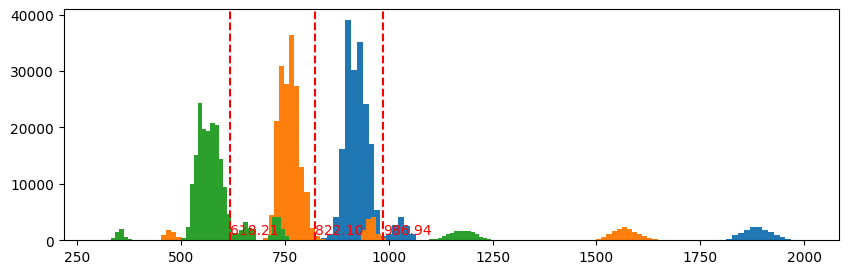

In [38]:
import h5py

def calculate_uc_area(h5_file, group='test'):
    with h5py.File(h5_file, 'r') as f:
        va = np.array(f[group]['primitive_uc_vector_a'])
        vb = np.array(f[group]['primitive_uc_vector_b'])
        shapes = f[group]['shape']
        shape_dict = { 'rectangular': 0, 'square': 0, 'oblique': 1, 'hexagonal': 1, 'rhombic': 2, 'triangle': 3 }
        shape_dict_inv = {v: k for k, v in shape_dict.items()}  
        shapes = [shape_dict_inv[s] for s in shapes]

    areas = []
    for a, b, shape in zip(va, vb, shapes):
        if shape != 'triangle':
            areas.append(np.linalg.norm(np.cross(a, b)))
        else:
            areas.append(np.linalg.norm(np.cross(a, b)) / 2)
    return areas

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_rot_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')

areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')

areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')
plt.show()

In [39]:
keywords = ['atom_v5_200k', 'atom_v5_small_uc_800_200k']
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

../../saved_results/Dataset_benchmark/resnet50-atom_v5_200k_cm.npy
Accuracy: 84.10%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_800_200k-zoomed_to_960_cm.npy
Accuracy: 50.25%



In [113]:
986.94/822.1

1.2005108867534364

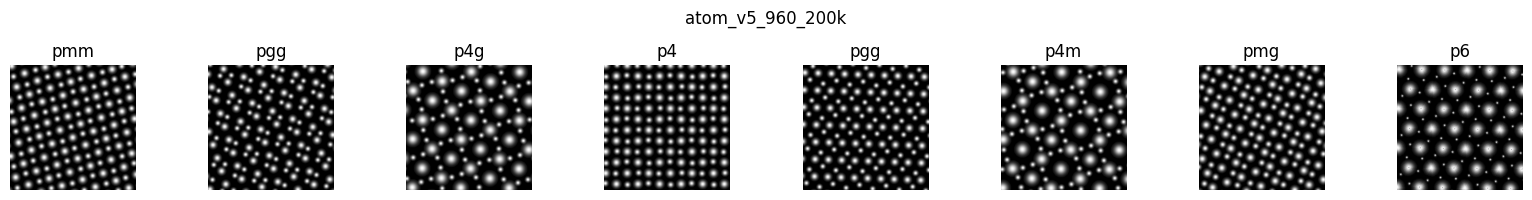

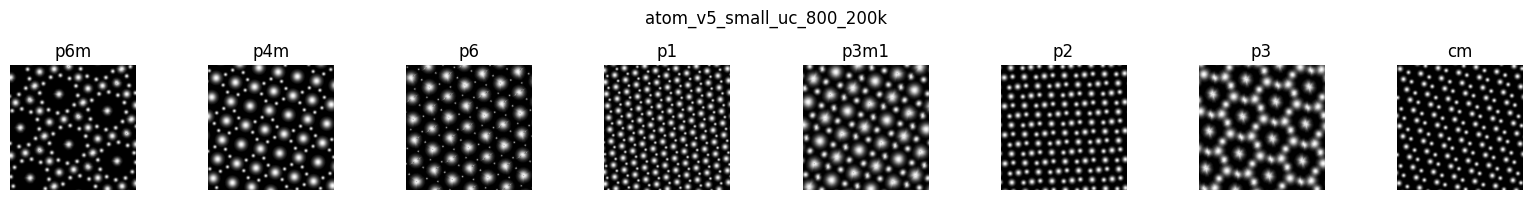

In [109]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom_v5_960_200k
atom_v5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_200k_dl = DataLoader(atom_v5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_200k_dl, label_converter=label_converter, title='atom_v5_960_200k')

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')

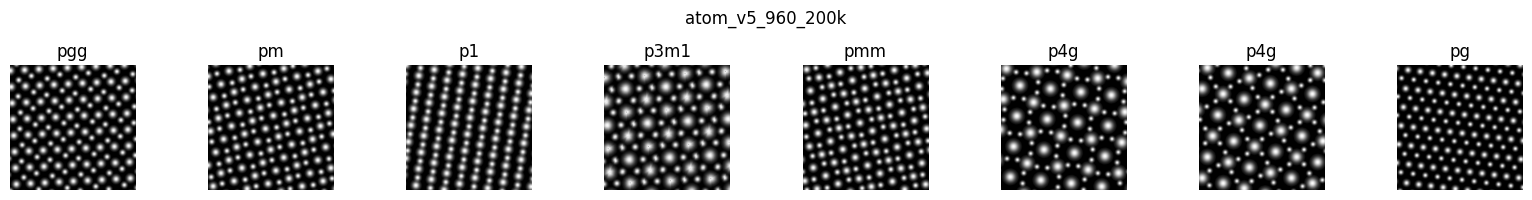

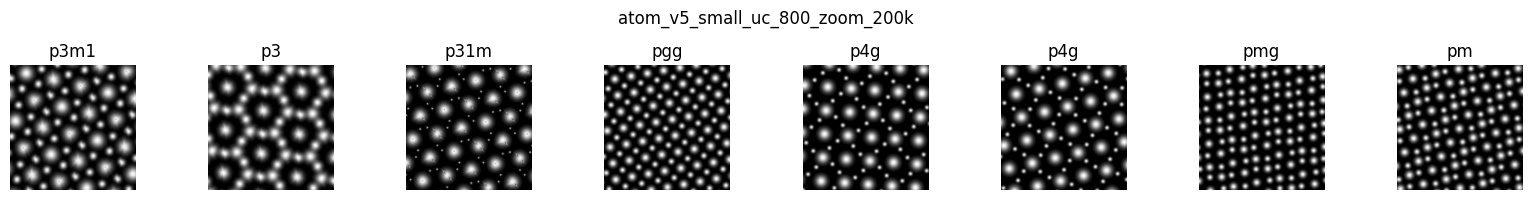

In [115]:
# atom_v5_960_200k
atom_v5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_200k_dl = DataLoader(atom_v5_200k_ds, batch_size=32, shuffle=False, num_workers=1)
viz_dataloader(atom_v5_200k_dl, label_converter=label_converter, title='atom_v5_960_200k')

# atom_v5_small_uc_800_zoom_200k
transform = transforms.Compose([ZoomTransform(zoom_range=(960/800, 960/800), output_size=(256, 256)), transforms.ToTensor()])
atom_v5_small_uc_800_zoom_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transform)
atom_v5_small_uc_800_zoom_200k_dl = DataLoader(atom_v5_small_uc_800_zoom_200k_ds, batch_size=32, shuffle=False, num_workers=1)
viz_dataloader(atom_v5_small_uc_800_zoom_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_zoom_200k')

In [114]:
name = 'atom_v5_small_uc_800_zoom_200k'
cm = confusion_matrix(model, atom_v5_small_uc_800_zoom_200k_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)

100%|██████████| 399/399 [41:26<00:00,  6.23s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 58.20490196078432%
